#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Data

In [3]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/transfer_data_tf.csv', index_col = 0)
rna

,ENSG00000164930,ENSG00000064961,ENSG00000074219,ENSG00000077150,ENSG00000169136,ENSG00000197905,ENSG00000124226,ENSG00000159184,ENSG00000137166,ENSG00000108654,...,ENSG00000124160,ENSG00000123358,ENSG00000004399,ENSG00000125520,ENSG00000101126,ENSG00000147889,ENSG00000116670,ENSG00000144802,ENSG00000075891,ENSG00000096696
MSKC-00397,14.529881,115.192800,29.841657,79.471610,65.262479,28.886094,137.021485,1.367006,14.180497,390.247090,...,36.296144,42.470505,72.975298,63.532046,36.014415,17.282096,21.648789,29.726232,3.186778,13.814659
MSKC-00399,24.450902,85.443224,40.405652,28.476253,30.171780,15.768220,118.166876,0.041264,22.427154,470.020002,...,44.311957,495.693384,43.022897,175.405866,47.074926,0.120574,28.120433,18.446672,81.676243,25.055237
MSKC-00400,12.766091,72.159172,25.769314,69.764160,15.898116,23.326659,102.403094,0.000000,9.814876,661.204682,...,49.922937,594.446477,98.383284,211.376486,48.502388,5.572871,17.698377,7.095124,79.121663,0.150022
MSKC-00404,18.893303,73.005636,40.702548,69.259393,53.030034,17.373790,97.193476,0.157535,14.712511,552.384331,...,35.741463,32.959601,133.397273,65.169623,42.266594,12.620565,30.082792,24.671674,0.124966,6.152555
MSKC-00405,33.396663,71.878100,41.783107,54.901434,51.195302,27.794177,108.183866,4.507236,18.594852,612.888369,...,39.385257,115.493379,168.217895,77.232286,53.303826,7.339189,23.447374,31.832615,45.525000,17.316586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT-P44H,1.135020,5.492578,0.235548,1.823922,6.448137,0.080267,10.407573,0.000000,1.858637,189.931256,...,3.809471,1.123306,4.145386,14.960947,11.474979,0.153551,2.356454,0.835196,0.004874,0.558164
PT-R55F,1.584404,4.856074,0.378914,3.443551,4.386524,0.173131,10.427795,0.000000,1.560770,211.971716,...,4.355030,1.097108,8.373387,11.883272,11.621491,0.120283,2.212391,1.150066,0.010036,0.823174
PT-RN5K,1.645791,8.187012,0.913826,9.650913,4.019023,0.255058,11.193488,0.000000,2.737795,217.249014,...,3.650723,1.422093,7.316858,19.236916,10.292509,0.132491,2.248747,2.221614,0.001018,1.674536
PT-UTHO,1.466925,9.055514,0.616683,5.029287,3.301576,0.098048,15.217994,0.000000,1.740849,360.455461,...,4.942725,2.666483,9.277073,9.273338,16.821428,0.358436,3.107594,2.247789,0.008052,1.009565


In [4]:
metabolites = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/metabolomics_log2.csv', index_col = 0)
metabolites = metabolites.T
metabolites

,"1,2-propanediol","1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-eicosatrienoylglycerophosphocholine (20:3),1-margaroylglycerophosphocholine (17:0),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-linoleoylglycerophosphoethanolamine,...,malonate,metronidazole,N-carboxymethylalanine,N1-Methyl-4-pyridone-3-carboxamide,N6-methyladenosine,nicotinate ribonucleoside,norfluoxetine,palmitoleoyl ethanolamide,succinimide,thyroxine
DUKE-00651,21.037723,19.394321,17.671134,14.233610,14.384728,16.818972,15.262543,14.061858,18.733537,13.836203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00652,23.959087,19.044231,14.631118,16.423374,16.305192,13.493080,13.337998,16.244013,14.342457,14.410637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00653,20.682481,19.193116,15.608743,14.400485,15.299840,14.887658,14.486196,15.090475,16.891647,14.514168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00654,19.963768,19.653941,15.383235,15.369813,14.913759,14.578475,13.337998,14.576805,17.531595,16.108259,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00657,19.677653,20.145794,17.854153,14.785590,14.445883,16.213699,13.337998,14.759995,19.931038,15.195652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,NaN,20.623605,20.772511,22.201466,23.203913,NaN,NaN,23.400548,21.974739,NaN,...,20.905649,19.987368,13.949308,18.857947,18.121721,15.876410,21.917796,14.204030,16.028156,13.218192
MSKC-00484,NaN,19.709740,21.012143,21.916148,21.409801,NaN,NaN,22.066585,23.908872,NaN,...,19.997085,19.987368,18.341589,15.813626,18.832340,15.876410,21.917796,14.081109,15.167041,13.218192
MSKC-00485,NaN,19.393769,20.316594,20.322285,20.074359,NaN,NaN,19.395849,21.530004,NaN,...,20.422488,19.987368,17.367652,19.865964,16.375009,18.547371,21.917796,13.940225,16.306077,13.218192
MSKC-00486,NaN,18.795282,19.099814,21.605296,22.077745,NaN,NaN,21.328106,20.474841,NaN,...,20.117567,19.987368,17.310323,19.386511,16.781328,15.876410,21.917796,13.940225,20.522298,13.218192


In [5]:
threshold = 0.2
nan_percentage = metabolites.isnull().mean()
filtered_metabolites = metabolites.loc[:, nan_percentage <= threshold]
metabolites = filtered_metabolites
metabolites

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
DUKE-00651,19.394321,17.671134,14.233610,14.384728,14.061858,18.733537,14.160222,17.035593,18.238785,16.193003,...,19.791208,17.280007,20.914748,13.103914,15.290542,11.141052,NaN,NaN,NaN,NaN
DUKE-00652,19.044231,14.631118,16.423374,16.305192,16.244013,14.342457,14.630229,17.097542,14.162099,16.343955,...,20.714696,17.931028,20.966490,11.180255,14.081160,15.169395,NaN,NaN,NaN,NaN
DUKE-00653,19.193116,15.608743,14.400485,15.299840,15.090475,16.891647,14.793942,16.787389,15.598227,16.307270,...,20.026746,17.416825,20.626487,12.483334,13.719496,10.940461,NaN,NaN,NaN,NaN
DUKE-00654,19.653941,15.383235,15.369813,14.913759,14.576805,17.531595,13.698657,17.498170,15.382139,14.735908,...,19.417532,17.333397,20.786484,12.785167,15.008995,11.457243,NaN,NaN,NaN,NaN
DUKE-00657,20.145794,17.854153,14.785590,14.445883,14.759995,19.931038,14.140832,16.189295,16.830153,13.092027,...,20.029593,18.298603,20.829264,12.072888,12.760453,10.473938,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,20.623605,20.772511,22.201466,23.203913,23.400548,21.974739,23.832628,21.126642,15.528993,23.714071,...,23.642103,22.356899,26.906058,13.804900,20.249497,18.873510,21.795535,21.284580,19.835953,20.788527
MSKC-00484,19.709740,21.012143,21.916148,21.409801,22.066585,23.908872,22.744470,24.818447,19.777455,22.367748,...,23.335062,18.983131,28.243038,16.627670,19.755282,19.011004,22.483612,22.112696,17.565157,21.367133
MSKC-00485,19.393769,20.316594,20.322285,20.074359,19.395849,21.530004,21.115255,21.695953,17.689438,22.340078,...,24.068418,21.271504,28.150188,13.804900,21.861710,20.761065,20.709723,22.940596,19.620601,19.702365
MSKC-00486,18.795282,19.099814,21.605296,22.077745,21.328106,20.474841,22.967082,21.579612,16.366178,22.815021,...,24.338312,22.174396,28.327350,15.008651,21.947564,18.447479,20.908825,21.293467,17.466552,20.561626


#Log2 transformation

In [6]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000164930,ENSG00000064961,ENSG00000074219,ENSG00000077150,ENSG00000169136,ENSG00000197905,ENSG00000124226,ENSG00000159184,ENSG00000137166,ENSG00000108654,...,ENSG00000124160,ENSG00000123358,ENSG00000004399,ENSG00000125520,ENSG00000101126,ENSG00000147889,ENSG00000116670,ENSG00000144802,ENSG00000075891,ENSG00000096696
MSKC-00397,3.956975,6.860377,4.946808,6.330408,6.050120,4.901402,7.108749,1.243063,3.924147,8.611936,...,5.220955,5.441965,6.208972,6.011944,5.210015,4.192360,4.501362,4.941399,2.065840,3.888954
MSKC-00399,4.669645,6.433681,5.371756,4.881481,4.962169,4.067658,6.896839,0.058335,4.550110,8.879645,...,5.501820,8.956212,5.460182,7.462755,5.587213,0.164238,4.863960,4.281451,6.369401,4.703501
MSKC-00400,3.783047,6.192967,4.742508,6.144947,4.078790,4.604466,6.692136,0.000000,3.434945,9.371133,...,5.670244,9.217828,6.634931,7.730480,5.629426,2.716524,4.224841,3.017053,6.324120,0.201662


#Data shuffling

In [7]:
combined_data = pd.concat([rna, metabolites], axis=1)
shuffled_data = combined_data.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
shuffled_metabolites = shuffled_data[metabolites.columns]

rna = shuffled_rna
metabolites = shuffled_metabolites

#Data imputation and normalization [-1, 1]

In [8]:
from sklearn.impute import SimpleImputer

def impute_normalize(df):
  data = df.copy()
  imputer = SimpleImputer(strategy='median')
  data = imputer.fit_transform(data)
  min_val = np.min(data)
  max_val = np.max(data)
  data_scaled = 2 * ((data - min_val) / (max_val - min_val)) - 1
  data_scaled = data_scaled.astype(np.float32)
  print('min:', np.min(data_scaled))
  print('max:', np.max(data_scaled))
  print('shape:', data_scaled.shape)

  return data_scaled

#Neural network

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [10]:
import pickle

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_tfs_nn_model_input_features.pkl', 'rb') as f:
  input_features = pickle.load(f)

input_features

['ENSG00000164930',
 'ENSG00000064961',
 'ENSG00000074219',
 'ENSG00000077150',
 'ENSG00000169136',
 'ENSG00000197905',
 'ENSG00000124226',
 'ENSG00000159184',
 'ENSG00000137166',
 'ENSG00000108654',
 'ENSG00000168496',
 'ENSG00000055130',
 'ENSG00000163132',
 'ENSG00000124575',
 'ENSG00000165672',
 'ENSG00000107447',
 'ENSG00000126778',
 'ENSG00000113068',
 'ENSG00000112715',
 'ENSG00000163558',
 'ENSG00000215301',
 'ENSG00000087191',
 'ENSG00000135111',
 'ENSG00000111206',
 'ENSG00000168283',
 'ENSG00000117318',
 'ENSG00000213676',
 'ENSG00000172534',
 'ENSG00000144485',
 'ENSG00000114554',
 'ENSG00000115641',
 'ENSG00000165030',
 'ENSG00000106261',
 'ENSG00000196843',
 'ENSG00000196975',
 'ENSG00000106483',
 'ENSG00000136997',
 'ENSG00000135363',
 'ENSG00000103994',
 'ENSG00000173253',
 'ENSG00000180818',
 'ENSG00000197780',
 'ENSG00000204209',
 'ENSG00000157933',
 'ENSG00000118418',
 'ENSG00000185650',
 'ENSG00000164920',
 'ENSG00000170608',
 'ENSG00000082175',
 'ENSG00000137310',


In [11]:
rna = rna.reindex(columns=input_features)
rna.head(3)

,ENSG00000164930,ENSG00000064961,ENSG00000074219,ENSG00000077150,ENSG00000169136,ENSG00000197905,ENSG00000124226,ENSG00000159184,ENSG00000137166,ENSG00000108654,...,ENSG00000124160,ENSG00000123358,ENSG00000004399,ENSG00000125520,ENSG00000101126,ENSG00000147889,ENSG00000116670,ENSG00000144802,ENSG00000075891,ENSG00000096696
MSKC-00659,5.399876,6.257115,5.656487,5.747899,3.613118,4.156797,6.374471,0.063930,4.663844,9.012501,...,5.397460,5.194403,6.486278,6.326358,6.731117,0.581580,4.333262,6.426058,5.562478,6.824403
CORN-01919,2.446212,6.340186,2.622874,7.762166,7.090305,1.254679,6.619267,0.000000,5.020240,9.694236,...,5.924337,3.971258,4.648400,5.309125,6.295976,5.257293,5.792465,5.779686,0.598006,0.213411
DUKE-00653,2.912790,7.574616,6.496158,5.012238,4.959148,3.741042,6.634274,5.137395,6.396607,7.539998,...,6.033685,4.156283,5.277150,7.933639,6.719573,2.606080,6.026306,3.191891,0.066144,7.947085


In [12]:
X = rna.values
y = metabolites.values

In [13]:
print(X.shape)
print(y.shape)

(443, 682)
(443, 218)


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2, random_state = 0)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 0)

X_train = impute_normalize(X_train)
X_test = impute_normalize(X_test)
X_val = impute_normalize(X_val)
y_train = impute_normalize(y_train)
y_test = impute_normalize(y_test)
y_val = impute_normalize(y_val)

print('Train data:')
print(X_train.shape)
print(y_train.shape)

print('Test data:')
print(X_test.shape)
print(y_test.shape)

print('Val data:')
print(X_val.shape)
print(y_val.shape)

min: -1.0
max: 1.0
shape: (354, 682)
min: -1.0
max: 1.0
shape: (44, 682)
min: -1.0
max: 1.0
shape: (45, 682)
min: -1.0
max: 1.0
shape: (354, 218)
min: -1.0
max: 1.0
shape: (44, 218)
min: -1.0
max: 1.0
shape: (45, 218)
Train data:
(354, 682)
(354, 218)
Test data:
(44, 682)
(44, 218)
Val data:
(45, 682)
(45, 218)


In [15]:
model = tf.keras.models.load_model('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_tfs_nn_model.keras')

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │       699,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081,669 (15.57 MB)

 Trainable params: 1,359,361 (5.19 MB)

 Non-trainable params: 3,584 (14.00 KB)

 Optimizer params: 2,718,724 (10.37 MB)

In [17]:
model.layers

[<Dense name=dense, built=True>,
 <BatchNormalization name=batch_normalization, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>,
 <BatchNormalization name=batch_normalization_1, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Dense name=dense_2, built=True>,
 <BatchNormalization name=batch_normalization_2, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_3, built=True>]

In [18]:
input_layer = model.layers[0].input

x = input_layer
for layer in model.layers[:-1]:
    x = layer(x)

num_new_outputs = y.shape[1]
new_output_layer = layers.Dense(num_new_outputs, activation='linear', name='new_output_dense')

output_tensor = new_output_layer(x)

new_model = tf.keras.Model(inputs=input_layer, outputs=output_tensor)

for layer in new_model.layers[:-1]:
    layer.trainable = False

new_model.compile(optimizer='adam',
                  loss='mean_squared_error',
                  metrics=['mae'])

new_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 682)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       699,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_output_dense (Dense)        │ (None, 218)            │        56,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,418,714 (5.41 MB)

 Trainable params: 56,026 (218.85 KB)

 Non-trainable params: 1,362,688 (5.20 MB)

In [19]:
for layer in new_model.layers:
  print(layer.trainable)

False
False
False
False
False
False
False
False
False
False
True


In [20]:
history = new_model.fit(X_train, y_train,
                        epochs=1000,
                        batch_size=32,
                        validation_data=(X_val, y_val),
                        shuffle = True,
                        callbacks=[tf.keras.callbacks.EarlyStopping(patience=100, restore_best_weights=True)]
                        )

Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - loss: 0.2295 - mae: 0.3768 - val_loss: 0.1514 - val_mae: 0.2779
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1583 - mae: 0.3110 - val_loss: 0.1128 - val_mae: 0.2421
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1336 - mae: 0.2843 - val_loss: 0.0903 - val_mae: 0.2193
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1201 - mae: 0.2700 - val_loss: 0.0772 - val_mae: 0.2059
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1144 - mae: 0.2642 - val_loss: 0.0719 - val_mae: 0.1982
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1075 - mae: 0.2558 - val_loss: 0.0743 - val_mae: 0.2013
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1092 - mae: 0.2558 - val_loss: 0.0792 - val_mae: 0.2081
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1028 - mae: 0.2483 - val_loss: 0.0748 - val_mae: 0.2013
Epoch 9/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - 

In [21]:
new_model.save('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_tfs_nn_model.keras')

In [22]:
import pickle

model_features_input = rna.columns.to_list()
model_features_output = metabolites.columns.to_list()

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_tfs_nn_model_features_input.pkl', 'wb') as f:
    pickle.dump(model_features_input, f)

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_tfs_nn_model_features_output.pkl', 'wb') as f:
    pickle.dump(model_features_output, f)

In [23]:
loss, mae = new_model.evaluate(X_test, y_test, verbose=1)
print("Mean Absolute Error:", mae)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.0367 - mae: 0.1451
Mean Absolute Error: 0.1462576985359192


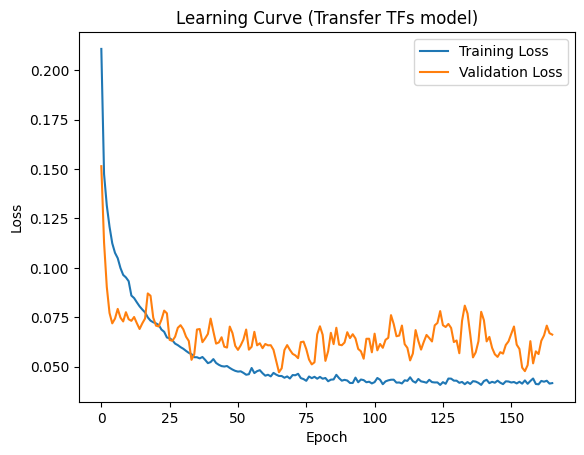

In [24]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve (Transfer TFs model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_model_tfs_learning_curve.svg', bbox_inches = 'tight')
plt.show()

In [25]:
train_loss = history.history['loss'][-1]
train_mae = history.history['mae'][-1]
print(f"Training Loss: {train_loss:.4f}")
print(f"Training MAE: {train_mae:.4f}")

Training Loss: 0.0417
Training MAE: 0.1524


In [26]:
val_loss = history.history['val_loss'][-1]
val_mae = history.history['val_mae'][-1]
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

Validation Loss: 0.0662
Validation MAE: 0.1912


In [27]:
loss, mae = new_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss: 0.0375
Test MAE: 0.1463


In [28]:
predictions = new_model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step


In [29]:
predictions.shape

(44, 218)

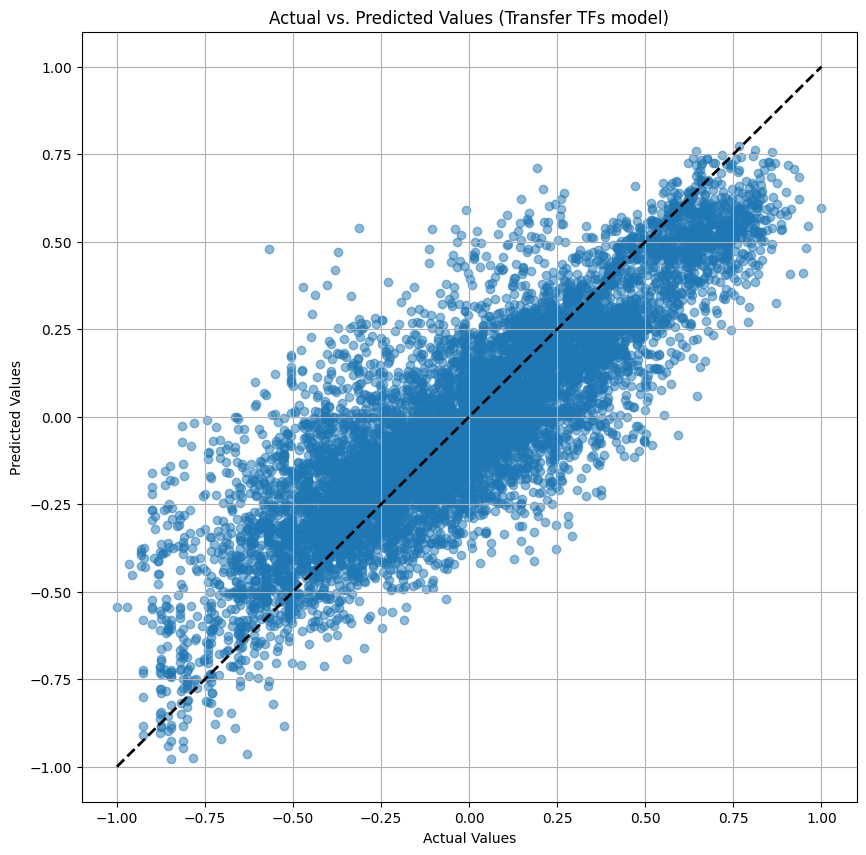

In [30]:
plt.figure(figsize=(10, 10))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min().min(), y_test.max().max()], [y_test.min().min(), y_test.max().max()], 'k--', lw=2, label='Ideal')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (Transfer TFs model)")
plt.grid(True)
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_tfs_model_actual_vs_pred.svg', bbox_inches = 'tight')
plt.show()

In [31]:
from sklearn.metrics import mean_squared_error

def get_metrics(y_predicted):

  mse = mean_squared_error(y_test, y_predicted)
  print("MSE:", mse)

  from sklearn.metrics import mean_absolute_error
  mae = mean_absolute_error(y_test, y_predicted)
  print("MAE:", mae)

  from sklearn.metrics import median_absolute_error
  medae = median_absolute_error(y_test, y_predicted,)
  print("MedAE:", medae)

  def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

  mape = mean_absolute_percentage_error(y_test, y_predicted)
  print('Mean absolute percentage error:', mape)

In [32]:
get_metrics(y_predicted = predictions)

MSE: 0.0374799445271492
MAE: 0.1462576985359192
MedAE: 0.120293155
Mean absolute percentage error: 221.74467


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


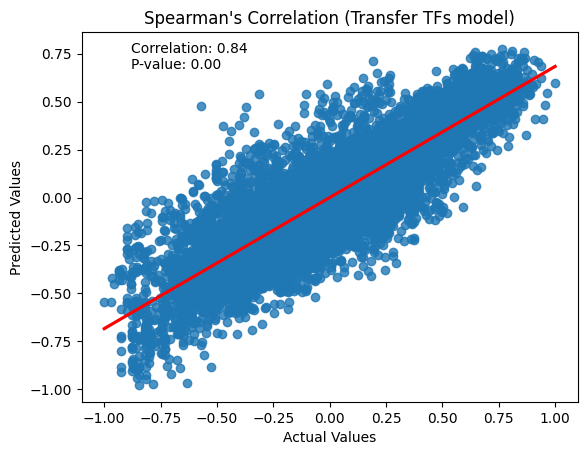

In [33]:
from scipy.stats import spearmanr

def get_spearman_correlation(model_predictions):

  correlation, p_value = spearmanr(X_test, model_predictions)

  correlation_df = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': model_predictions.flatten()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation (Transfer TFs model)')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_tfs_model_spearmans_reg_plot.svg', bbox_inches = 'tight')
  plt.show()


get_spearman_correlation(predictions)

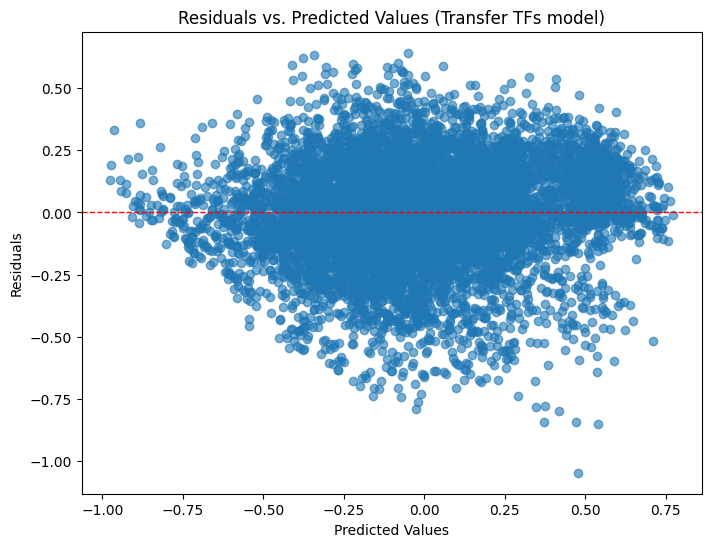

In [34]:
#Checking for heteroscedasticity
!pip install statsmodels

import statsmodels.api as sm

def get_residuals_vs_pred_plot(model_predictions):

  residuals = (y_test - model_predictions).ravel()

  plt.figure(figsize=(8, 6))
  plt.scatter(model_predictions.ravel(), residuals, alpha=0.6)
  plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
  plt.title(f"Residuals vs. Predicted Values (Transfer TFs model)")
  plt.xlabel("Predicted Values")
  plt.ylabel("Residuals")
  plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_tfs_model_residuals.svg', bbox_inches = 'tight')
  plt.show()

get_residuals_vs_pred_plot(predictions)

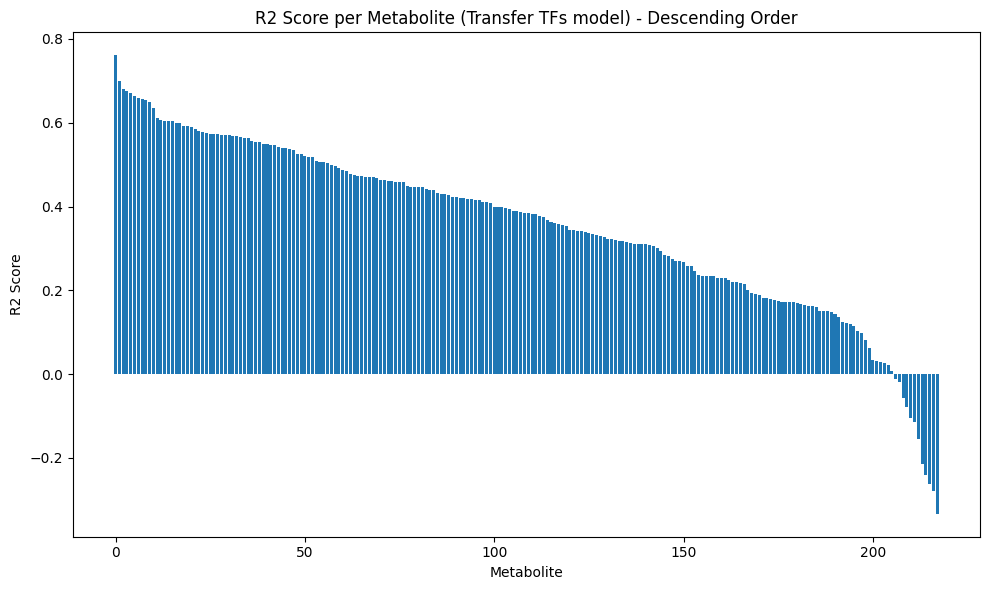

In [35]:
from sklearn.metrics import r2_score

def plot_r2_per_metabolite(y_true, y_pred, metabolite_names):
    """Plots the R2 score per metabolite for a given model in descending order."""

    r2_scores = []  # Initialize list to store R2 scores
    for i in range(y_true.shape[1]):  # Iterate through each metabolite (column)
        # Calculate R2 for the current metabolite across all samples
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        r2_scores.append(r2)  # Add the R2 score to the list

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': metabolite_names, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)
    r2_df.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/r2_df_transfer_tfs.csv', index =True)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(r2_df)), r2_df['R2 Score'])  # Create bar plot of R2 scores
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("R2 Score")
    plt.title(f"R2 Score per Metabolite (Transfer TFs model) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_tfs_model_r2_per_metabolite.svg', bbox_inches = 'tight')
    plt.show()

# Get the original metabolite names before splitting and normalization
original_metabolite_names = metabolites.columns

# Call the function with y_test, predictions, and original_metabolite_names
plot_r2_per_metabolite(y_test, predictions, original_metabolite_names)

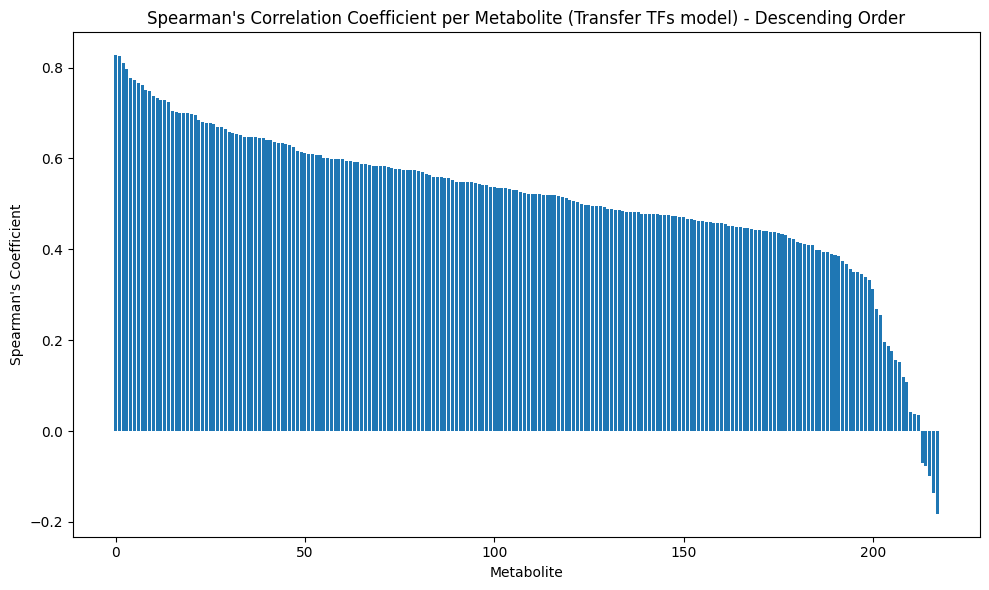

In [36]:
def plot_spearman_per_metabolite(y_true, y_pred, metabolite_names):
    """Plots the Spearman's correlation coefficient per metabolite for a given model."""

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_true.shape[1]):  # Iterate through each metabolite (column)
        # Ensure y_true and y_pred for the current metabolite are 1D arrays
        coeff, _ = spearmanr(y_true[:, i].ravel(), y_pred[:, i].ravel())  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting using metabolite names
    spearman_df = pd.DataFrame({'Metabolite': metabolite_names, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)
    spearman_df.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/spearman_df_transfer_tfs.csv', index =True)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    # Use the metabolite names from the sorted DataFrame for x-axis labels
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])  # Create bar plot of coefficients
    plt.xticks()  # Set x-axis labels to metabolite names and rotate them
    plt.xlabel("Metabolite")
    plt.ylabel("Spearman's Coefficient")
    plt.title(f"Spearman's Correlation Coefficient per Metabolite (Transfer TFs model) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_tfs_model_spearmans_per_metabolite.svg', bbox_inches = 'tight')
    plt.show()

original_metabolite_names = metabolites.columns

# Call the function with y_test, predictions, and original_metabolite_names
plot_spearman_per_metabolite(y_test, predictions, original_metabolite_names)